In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer



In [94]:
## Loading the data 
data = pd.read_csv("Train.csv")

In [95]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [96]:
data.shape

(8523, 12)

In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [98]:
data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [99]:
data['Item_Weight'].fillna(data['Item_Weight'].mean(), inplace=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_17228\589977742.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Item_Weight'].fillna(data['Item_Weight'].mean(), inplace=True)


In [100]:
mode_data = data.pivot_table(values='Outlet_Size' , columns= 'Outlet_Type' , aggfunc=(lambda x:x.mode()[0]))

In [101]:
missing_values = data['Outlet_Size'].isnull()

In [102]:
data.loc[missing_values, 'Outlet_Size'] = (
    data.loc[missing_values, 'Outlet_Type']
    .apply(lambda x: mode_data[x][0])
)

C:\Users\HP\AppData\Local\Temp\ipykernel_17228\1068622970.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .apply(lambda x: mode_data[x][0])


In [103]:
data.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [104]:
data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [105]:
sns.set()

C:\Users\HP\AppData\Local\Temp\ipykernel_17228\999927318.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Item_Weight'])


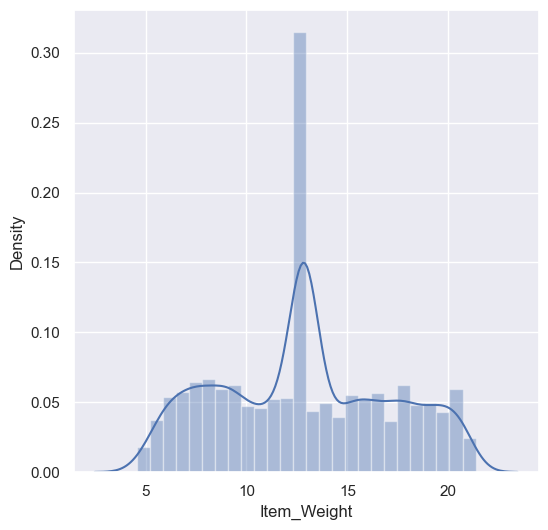

In [106]:
# item wrigth distribution
plt.figure(figsize=(6,6))
sns.distplot(data['Item_Weight'])
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_17228\715201230.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Item_Visibility'])


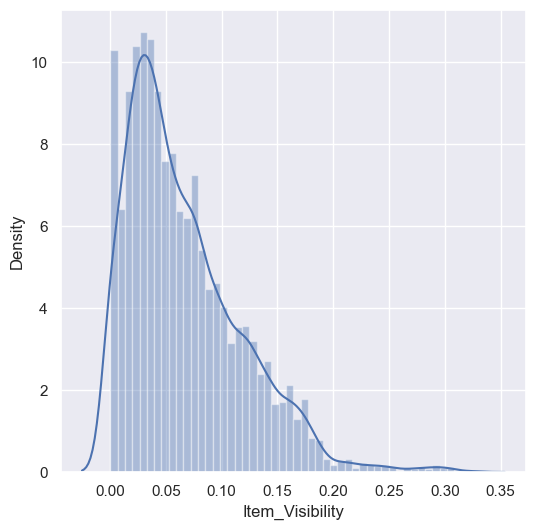

In [107]:
# item wrigth distribution
plt.figure(figsize=(6,6))
sns.distplot(data['Item_Visibility'])
plt.show()

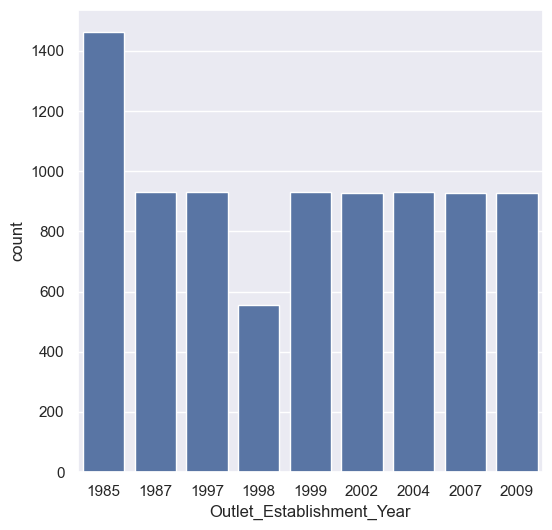

In [108]:
# item wrigth distribution
plt.figure(figsize=(6,6))
sns.countplot(x = "Outlet_Establishment_Year", data = data)
plt.show()

In [109]:
## Seperating the features and target
X = data.drop("Item_Outlet_Sales", axis=1)
Y = data["Item_Outlet_Sales"]

In [110]:
## Splitting into tain Test split 
X_train , X_test , Y_train , Y_test = train_test_split(X, Y, test_size=0.2, random_state=42 )

In [111]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

In [112]:
num_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy="median") )
])

In [113]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder" , OneHotEncoder(handle_unknown="ignore"))
])

In [114]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline , num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [115]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor())
])

In [116]:
model.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [117]:
## Train Evaluation and prediction 
Train_pred = model.predict(X_train)

Train_score = metrics.r2_score(Y_train, Train_pred)

Train_score

0.7193683018431583

In [118]:
## teting evaluatio nand prediction 
Test_pred = model.predict(X_test)

Test_score = metrics.r2_score(Y_test, Test_pred)

Test_score

0.569474516324578

In [121]:
## Building a predictive system 
input_data = [
    'FDL48',
    19.35,
    'Regular',
    0.082601537,
    'Baking Goods',
    50.1034,
    'OUT018',
    2009,
    'Medium',
    'Tier 3',
    'Supermarket Type2'
]


input_df = pd.DataFrame([input_data], columns=X.columns)

Prediction = model.predict(input_df)

print(f"Model predicted the sales as : {Prediction[0]}")

Model predicted the sales as : 615.572509765625
